## Intitialisation

In [1]:
from scripts.AbstractExperiments import ExperimentRunner, GenerateConfigs
from EnvironmentBuilder.SearchRescue.Rescue import Rescue
import EnvironmentBuilder.SearchRescue.Drawing as SearchRescueDraw
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"

In [2]:
def GenerateTeamConfigs(teams_:list, name_prefix=None):
    configs = {}
    if name_prefix is None:
        name_prefix = f"{len(teams_)}_"
    # Act-Utilitarianism
    con = {"Theories": [["Add_Util", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", "Add_Util"])
    configs[f"{name_prefix}add"] = con

    # Balance
    con = {"Theories": [], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", f"{t}"])
    configs[f"{name_prefix}bal"] = con

    # Fairness
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Fair"]])
    configs[f"{name_prefix}fair"] = con

    # Fairness + Others
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Fair"]])
    configs[f"{name_prefix}fair_bal"] = con

    # Fairness + Act-Utilitarianism
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Fair"]])
    configs[f"{len(teams_)}fair_AU"] = con

    # Rawls
    con = {"Theories":[["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Rawls"]])
    configs[f"{name_prefix}rawl"] = con

    # Rawls + Others
    con = {"Theories": [["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Rawls"]])
    configs[f"{name_prefix}rawl_bal"] = con

    # Rawls + AU
    con = {"Theories": [["Rawls", "Maximin", 0], ["Add_Util", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", ["Rawls", "Add_Util"]])
    configs[f"{name_prefix}rawl_AU"] = con

    return configs

def MakeTeamWeights(teams_):
    p = [2**i for i in range(0, len(teams_))]
    total = sum(p)
    w = [i / total for i in p]
    o = {}
    for t in teams_:
        for i, t in enumerate(teams_):
            o[f"{t}_hosp_success"] = w[i]
    return o

markers = {
    "Separate Theories": "o",
    "Act-Utilitarianism": "s",
    "Fairness": "^",
    "Rawls": "*",
    "Fair + balance": ".",
    "Rawls + balance": "x"
}
colours = {
    "Separate Theories": "blue",
    "Act-Utilitarianism": "black",
    "Fairness": "green",
    "Rawls": "red",
    "Fair + balance": "cyan",
    "Rawls + balance": "magenta",
}

## Build the environements

In [30]:
configs = []
env_reps = 10
for horizon_ in range(3,7):
    for Comms in range(2,7):
        teams = [f"{i}" for i in range(Comms)]
        odds = MakeTeamWeights(teams)
        configs += GenerateConfigs(inputConfigs=GenerateTeamConfigs(teams, name_prefix=f"{len(teams)}_h{horizon_}"), 
            defaultConfig={"Horizon": horizon_, "Teams":teams, "unknown_depth": 0, "Odds":odds})

er = ExperimentRunner("Rescue", configs, MoralPlanner_Location="/../../", outFolder="ProfileRescue")
er.buildEnvironments()

Written Rescue MMMDP with 13 states and theories [{'Name': 'Add_Util', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/2026-07-26_16:18:51/mdps/2_h3add_con0.json

Written Rescue MMMDP with 13 states and theories [{'Name': '0', 'Type': 'Utility', 'Rank': 0}, {'Name': '1', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/2026-07-26_16:18:51/mdps/2_h3bal_con0.json

Written Rescue MMMDP with 13 states and theories [{'Name': 'Fair', 'Type': 'Fairness', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/2026-07-26_16:18:51/mdps/2_h3fair_con0.json

Written Rescue MMMDP with 13 states and theories [{'Name': 'Fair', 'Type': 'Fairness', 'Rank': 0}, {'Name': '0', 'Type': 'Utility', 'Rank': 0}, {'Name': '1', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/No

{'2_h3add': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x769b24344500>],
 '2_h3bal': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x769b24344320>],
 '2_h3fair': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x769b24344410>],
 '2_h3fair_bal': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x769b243448c0>],
 '2fair_AU': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x769b243456d0>,
 '2_h3rawl': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x769b243449b0>],
 '2_h3rawl_bal': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x769b24344b90>],
 '2_h3rawl_AU': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x769b24344c80>],
 '3_h3add': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x769b24344d70>],
 '3_h3bal': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x769b24345220>],
 '3_h3fair': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x769b24345130>],
 '3_h3fair_bal': [<EnvironmentBuilder.SearchRescue.Rescue.Rescue at 0x769b24344f50>],
 '3fai

## Run the planner

In [31]:
er.runPlanner(envRepetitions=env_reps)

EXECUTE /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../MPlan/cmake-build-release/MPlan --debug 0 /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/2026-07-26_16:18:51/mdps/2_h3add_con0.json /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/2026-07-26_16:18:51/raw/2_h3add_con0_rep0.json
THE 2026 MACHINE ETHICS HYPOTHETICAL RETROSPECTION PLANNER (MEHR-PLAN)
JSON file '/home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/2026-07-26_16:18:51/raw/2_h3add_con0_rep0.json' created successfully!
EXECUTE /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../MPlan/cmake-build-release/MPlan --debug 0 /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/2026-07-26_16:18:51/mdps/2_h3add_con0.json /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/2026-07-26_16:18:51/raw/2_h3add_c

In [40]:
er.extractData(1, env_reps)
df = pd.DataFrame(er.data)
df = df.drop(labels=['Conf_rep', 'Theories', 'Considerations', 'CQ1_time', 'CQ2_time', 'Out_time', 'Sol_reduce_time'], axis=1)
df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)
df['communities'] = df['Config_name'].str[:1]
df["Config_name"] = np.select(
    [
        df["Config_name"].str.contains("fair_bal", case=False, na=False),
        df["Config_name"].str.contains("fair_AU", case=False, na=False),
        df["Config_name"].str.contains("rawl_bal", case=False, na=False),
        df["Config_name"].str.contains("rawl_AU", case=False, na=False),
        df["Config_name"].str.contains("add", case=False, na=False),
        df["Config_name"].str.contains("bal", case=False, na=False),
        df["Config_name"].str.contains("fair", case=False, na=False),
        df["Config_name"].str.contains("rawl", case=False, na=False),
    ],
    [   
        "Fair + Separate",
        "Fair + AU",
        "Rawls + Separate",
        "Rawls + AU",
        "Act-Utilitarianism",
        "Separate Theories",
        "Fairness",
        "Rawls",
    ],
    default=df["Config_name"]
)
df.head(500)

,Config_name,Env_rep,Total_time,Heuristic_time,Plan_time,Sol_time,Mehr_time,Expanded_states,BSG_states,Average_histories,...,Num_of_sols,Total_Attacks,Total_reachable_policies,0:wellbeing,1:wellbeing,2:wellbeing,3:wellbeing,4:wellbeing,5:wellbeing,communities
0,Act-Utilitarianism,0,71,6,21,43,1,11,13,3,...,2,2,12,0,1.3333,NaN,NaN,NaN,NaN,2
1,Act-Utilitarianism,1,67,6,19,41,1,11,13,3,...,2,2,12,0,1.3333,NaN,NaN,NaN,NaN,2
2,Act-Utilitarianism,2,71,6,18,46,1,11,13,3,...,2,2,12,0,1.3333,NaN,NaN,NaN,NaN,2
3,Act-Utilitarianism,3,84,6,26,51,1,11,13,3,...,2,2,12,0,1.3333,NaN,NaN,NaN,NaN,2
4,Act-Utilitarianism,4,63,5,19,38,1,11,13,3,...,2,2,12,0,1.3333,NaN,NaN,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Separate Theories,5,168,11,56,99,2,23,25,4,...,3,24,165,0,0,1.7143,NaN,NaN,NaN,3
496,Separate Theories,6,211,14,71,124,2,23,25,4,...,3,24,165,0,0,1.7143,NaN,NaN,NaN,3
497,Separate Theories,7,179,12,61,104,2,23,25,4,...,3,24,165,0,0,1.7143,NaN,NaN,NaN,3
498,Separate Theories,8,225,11,58,154,2,23,25,4,...,3,24,165,0,0,1.7143,NaN,NaN,NaN,3


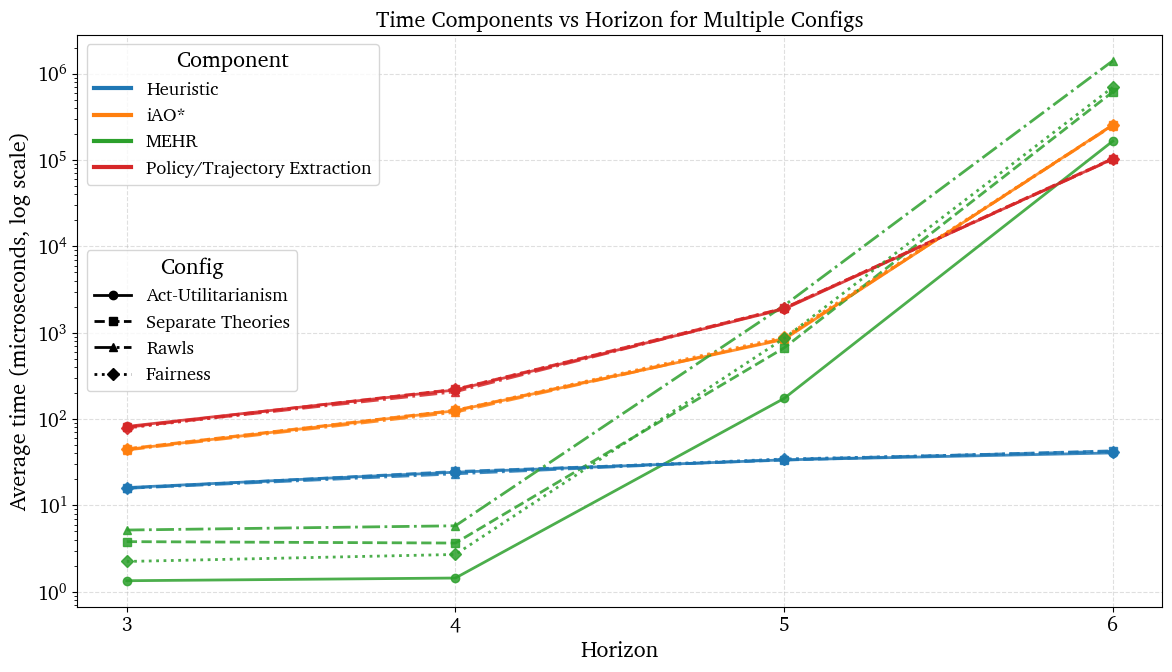

In [60]:
from matplotlib.lines import Line2D

config_names = ["Act-Utilitarianism", "Separate Theories", "Rawls", "Fairness"]
labels = {"Heuristic_time": "Heuristic", "Mehr_time": "MEHR", "Plan_time": "iAO*", "Sol_time": "Policy/Trajectory Extraction"}

average_durations = df[df['Config_name'].isin(config_names)].copy()
average_durations = average_durations.groupby(['Config_name', 'Horizon'])[ExperimentRunner.time_columns].mean().reset_index()
average_durations['Mehr_time'] = average_durations['Mehr_time'].replace(0, 0.0001)

cols = deepcopy(ExperimentRunner.time_columns)
cols.remove('Total_time')

plt.figure(figsize=(12, 7))

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
component_colors = {col: color_cycle[i % len(color_cycle)] for i, col in enumerate(cols)}
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'D', 'x', '*']

for cfg_idx, config in enumerate(config_names):
    config_group = average_durations[average_durations['Config_name'] == config]
    style = line_styles[cfg_idx % len(line_styles)]
    marker = markers[cfg_idx % len(markers)]
    for column in cols:
        plt.plot(
            config_group['Horizon'],
            config_group[column],
            linestyle=style,
            marker=marker,
            color=component_colors[column],
            label=f"latex_config_name(config)",
            alpha=0.85,
            linewidth=2,
            markersize=6,
        )



plt.title("Time Components vs Horizon for Multiple Configs")
plt.xlabel("Horizon")
plt.yscale("log")
plt.ylabel("Average time (microseconds, log scale)")
plt.xticks(ticks=np.arange(min(average_durations['Horizon']), max(average_durations['Horizon']) + 1, 1))

component_handles = [Line2D([0], [0], color=component_colors[col], lw=3) for col in cols]
config_handles = [Line2D([0], [0], color='black', lw=2, linestyle=line_styles[i % len(line_styles)], marker=markers[i % len(markers)]) for i in range(len(config_names))]

legend1 = plt.legend(component_handles, [labels[col] for col in cols], title='Component', loc='upper left', fontsize='small')
legend2 = plt.legend(config_handles, [c for c in config_names], title='Config', loc='center left', fontsize='small')
plt.gca().add_artist(legend1)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
plot_df = df.copy()
numeric_columns = [
    "Env_rep",
    "Horizon",
    "communities",
    "Mehr_time",
    "Total_time",
]
for column in numeric_columns:
    plot_df[column] = pd.to_numeric(plot_df[column], errors="coerce")

plot_df = plot_df.dropna(
    subset=[
        "Config_name",
        "Horizon",
        "communities",
        "Total_time",
    ]
)
# Combined problem-size measure.
plot_df["Horizon_x_communities"] = (
    plot_df["Horizon"] * plot_df["communities"]
)
plot_df

,Config_name,Env_rep,Total_time,Heuristic_time,Plan_time,Sol_time,Mehr_time,Expanded_states,BSG_states,Average_histories,...,Total_Attacks,Total_reachable_policies,0:wellbeing,1:wellbeing,2:wellbeing,3:wellbeing,4:wellbeing,5:wellbeing,communities,Horizon_x_communities
0,Act-Utilitarianism,0,71,6,21,43,1,11,13,3,...,2,12,0,1.3333,NaN,NaN,NaN,NaN,2,6
1,Act-Utilitarianism,1,67,6,19,41,1,11,13,3,...,2,12,0,1.3333,NaN,NaN,NaN,NaN,2,6
2,Act-Utilitarianism,2,71,6,18,46,1,11,13,3,...,2,12,0,1.3333,NaN,NaN,NaN,NaN,2,6
3,Act-Utilitarianism,3,84,6,26,51,1,11,13,3,...,2,12,0,1.3333,NaN,NaN,NaN,NaN,2,6
4,Act-Utilitarianism,4,63,5,19,38,1,11,13,3,...,2,12,0,1.3333,NaN,NaN,NaN,NaN,2,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,Rawls + AU,5,7608923,80,1035549,353558,6219736,70,72,6,...,74309,953168928,0,0.0177,0.012,0.0241,0.5079,0.0328,6,36
1596,Rawls + AU,6,7765197,84,1037256,353338,6374519,70,72,6,...,74309,953168928,0,0.0177,0.012,0.0241,0.5079,0.0328,6,36
1597,Rawls + AU,7,7675862,77,1062408,354498,6258879,70,72,6,...,74309,953168928,0,0.0177,0.012,0.0241,0.5079,0.0328,6,36
1598,Rawls + AU,8,7648614,84,1049154,350414,6248962,70,72,6,...,74309,953168928,0,0.0177,0.012,0.0241,0.5079,0.0328,6,36


In [42]:
average_times = (
    plot_df
    .groupby(
        [
            "Config_name",
            "Horizon",
            "communities",
            "Horizon_x_communities",
        ],
        as_index=False,
    )
    .agg(
        Average_total_time=("Total_time", "mean"),
        Minimum_total_time=("Total_time", "min"),
        Maximum_total_time=("Total_time", "max"),
        Standard_deviation=("Total_time", "std"),
        Number_of_repetitions=("Total_time", "size"),
    )
)

# A single repetition has no sample standard deviation.
average_times["Standard_deviation"] = (
    average_times["Standard_deviation"].fillna(0)
)

In [70]:
def plot_average_growth(
    data,
    x_column,
    x_label,
    title,
    configurations=None,
    use_log_scale=True,
    ticks_for_existing_values_only=True,
    no_legend=False,
    ax=None,
):
    # Create a new figure only when an axis was not supplied.
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        standalone_plot = True
    else:
        fig = ax.figure
        standalone_plot = False

    plot_data = data.copy()

    # Keep only the requested configurations.
    # Passing None plots every configuration.
    if configurations is not None:
        plot_data = plot_data[
            plot_data["Config_name"].isin(configurations)
        ]

    for configuration, configuration_data in plot_data.groupby(
        "Config_name",
        sort=False,
    ):
        line_data = (
            configuration_data
            .groupby(x_column, as_index=False)
            .agg(
                Average_total_time=("Average_total_time", "mean"),
            )
            .sort_values(x_column)
        )

        ax.plot(
            line_data[x_column],
            line_data["Average_total_time"],
            marker="o",
            linewidth=2,
            label=configuration,
        )

    ax.set_xlabel(x_label)
    ax.set_ylabel("Average total time")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    if use_log_scale:
        ax.set_yscale("log")
        ax.set_ylabel("Average total time (log scale)")

    if ticks_for_existing_values_only:
        existing_x_values = sorted(
            plot_data[x_column].dropna().unique()
        )
        ax.set_xticks(existing_x_values)

    if not no_legend:
        ax.legend(
            title="Configuration",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
        )

    # Only display immediately when this is an individual plot.
    if standalone_plot:
        fig.tight_layout()
        plt.show()

    return ax

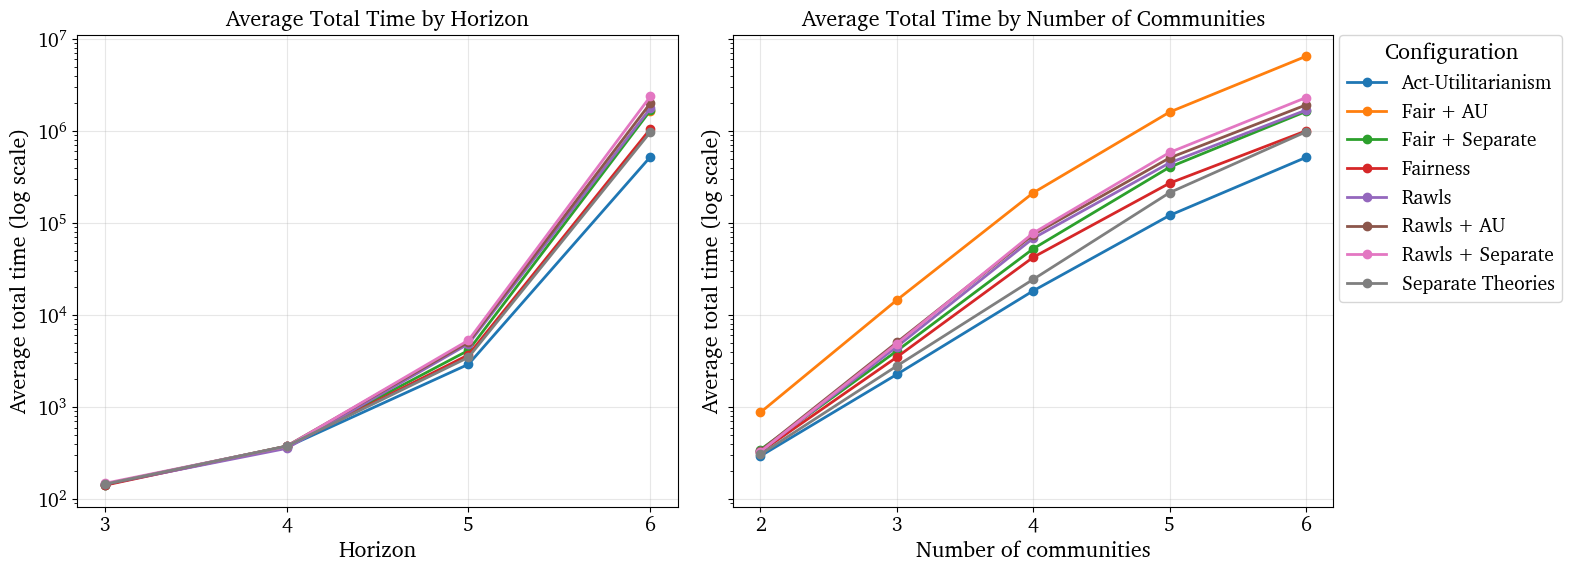

In [74]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6),
    sharey=True,
)

plot_average_growth(
    data=average_times,
    x_column="Horizon",
    x_label="Horizon",
    title="Average Total Time by Horizon",
    use_log_scale=True,
    no_legend=True,
    ax=axes[0],
)

plot_average_growth(
    data=average_times,
    x_column="communities",
    x_label="Number of communities",
    title="Average Total Time by Number of Communities",
    use_log_scale=True,
    no_legend=True,
    ax=axes[1],
)

# Put the shared legend immediately beside the right-hand graph.
handles, labels = axes[1].get_legend_handles_labels()

axes[1].legend(
    handles,
    labels,
    title="Configuration",
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0,
)

fig.tight_layout()
plt.show()

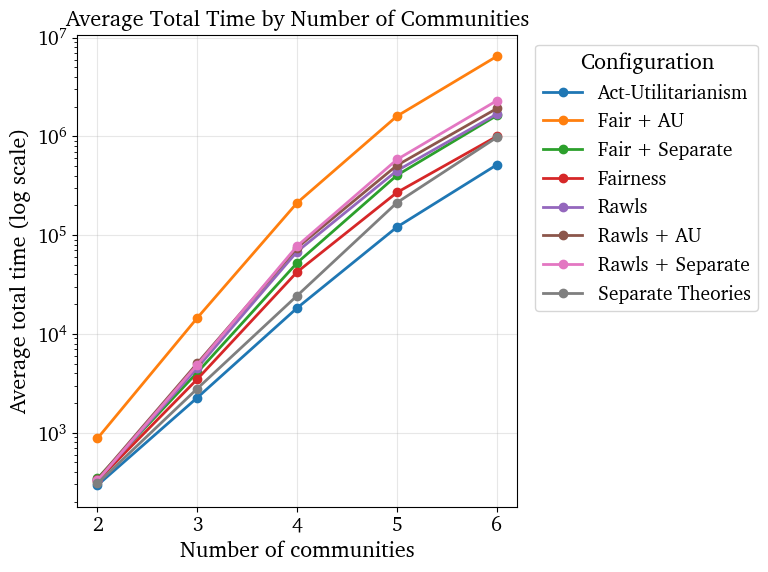

<Axes: title={'center': 'Average Total Time by Number of Communities'}, xlabel='Number of communities', ylabel='Average total time (log scale)'>

In [72]:
plot_average_growth(
    data=average_times,
    x_column="communities",
    x_label="Number of communities",
    title="Average Total Time by Number of Communities",
)


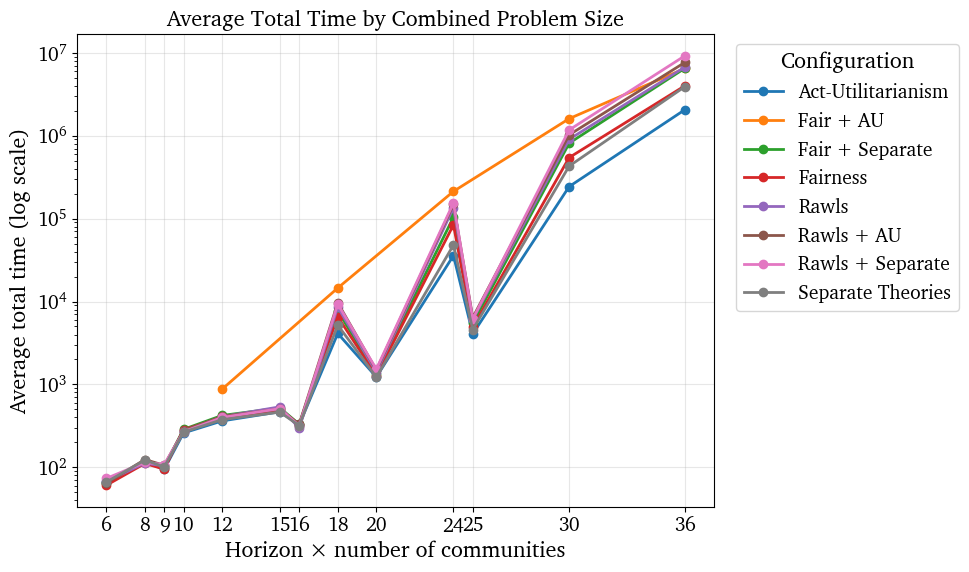

In [46]:
plot_average_growth(
    data=average_times,
    x_column="Horizon_x_communities",
    x_label="Horizon × number of communities",
    title="Average Total Time by Combined Problem Size",
)

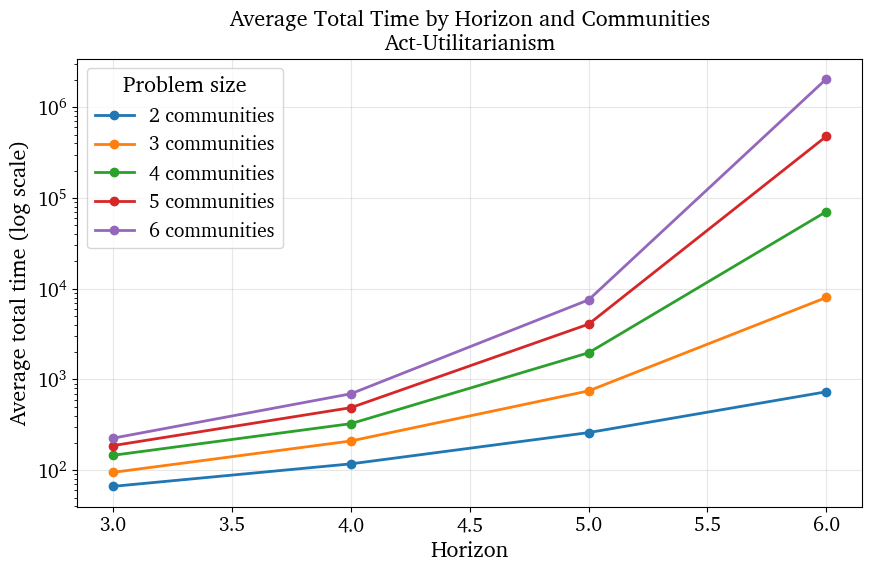

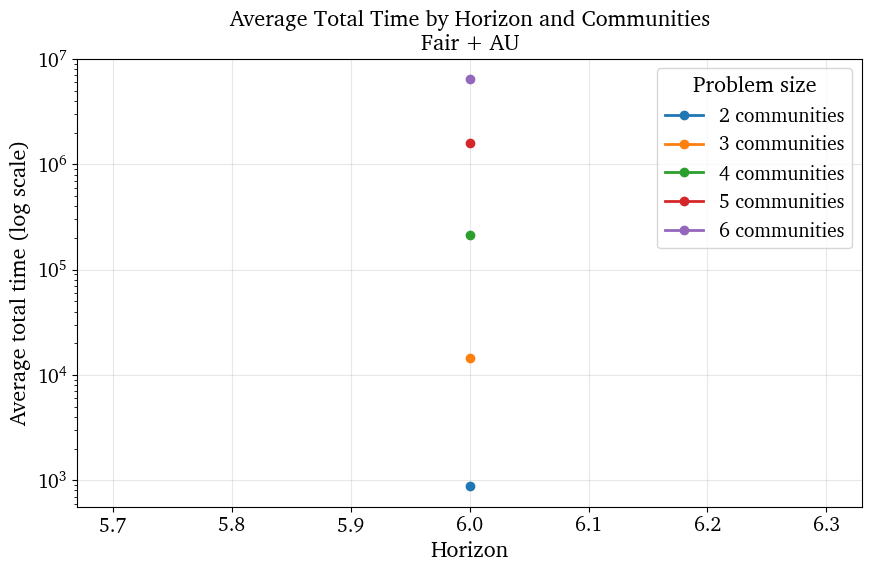

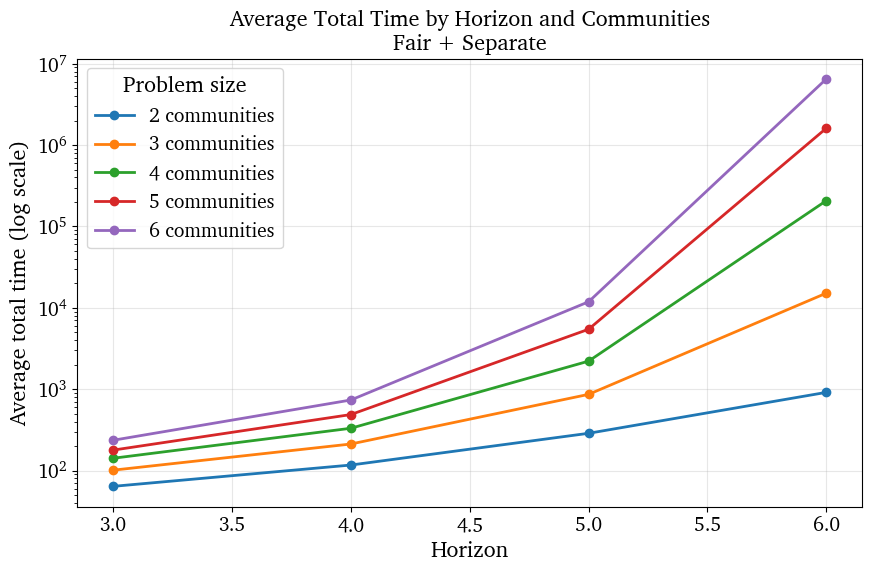

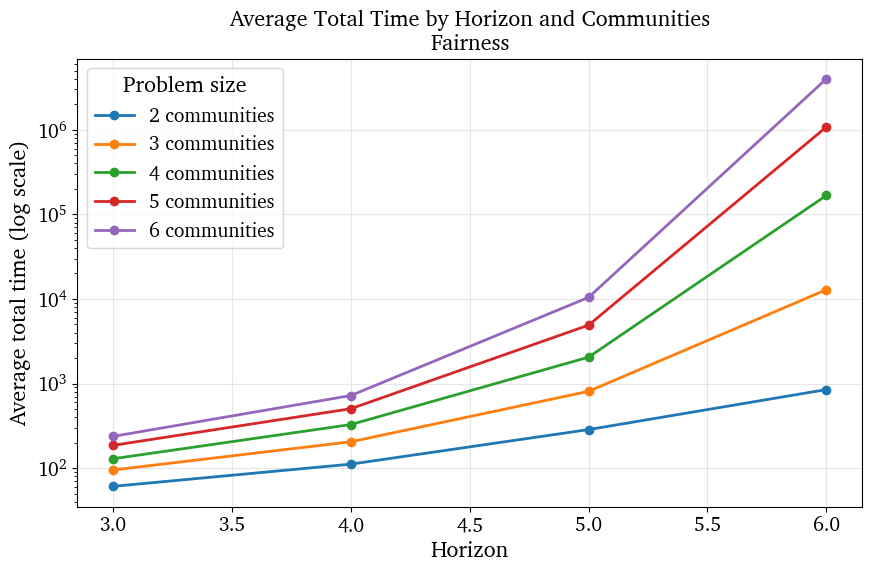

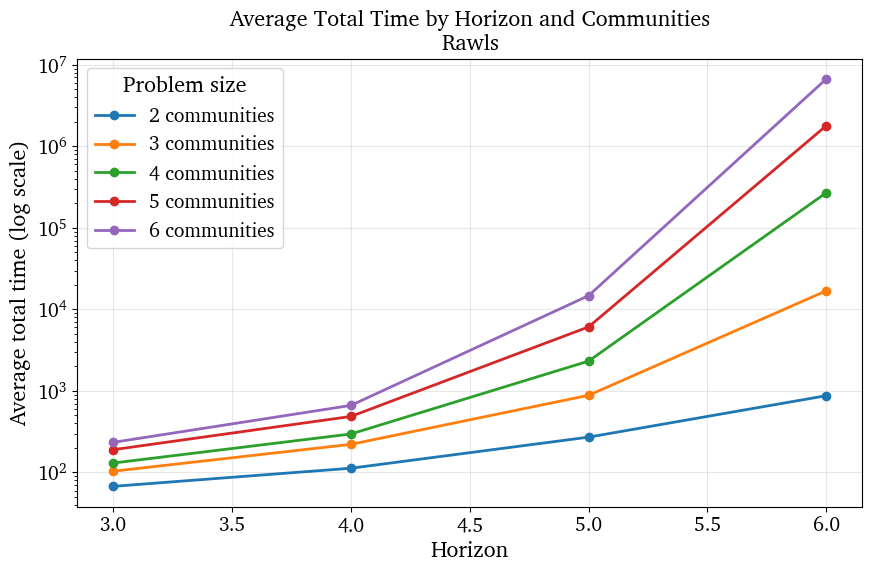

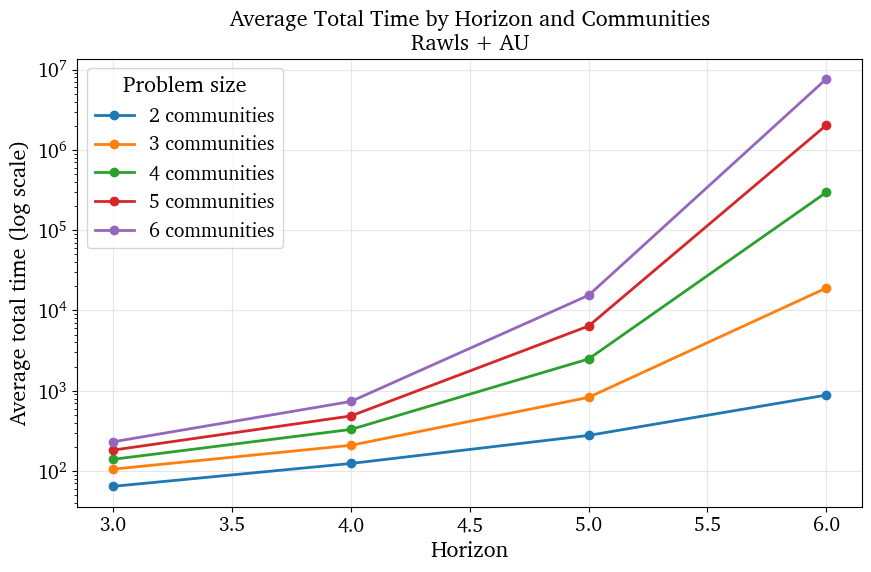

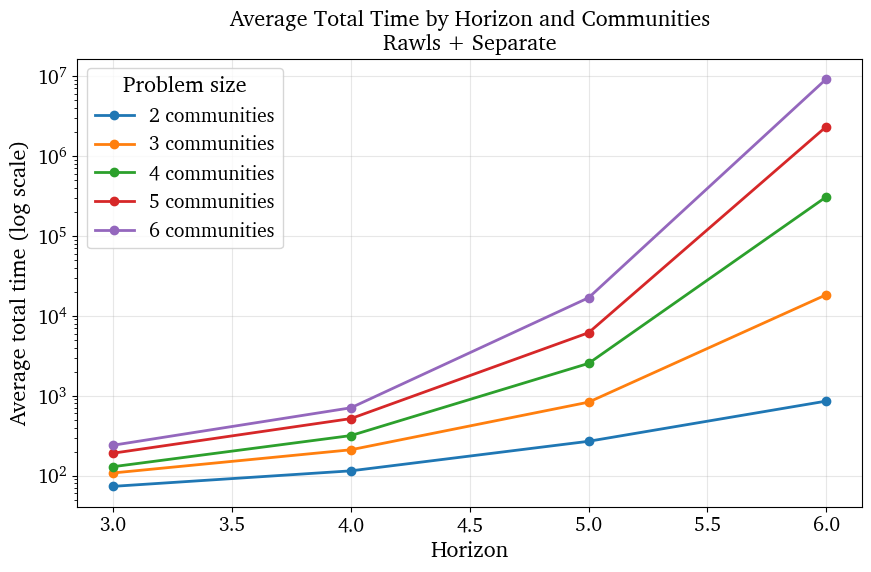

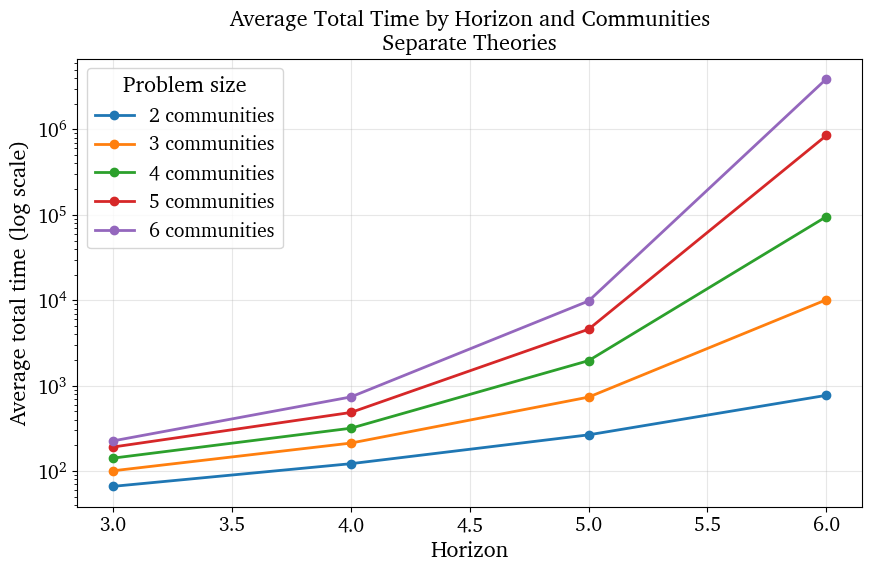

In [47]:
configurations = average_times["Config_name"].drop_duplicates()

for configuration in configurations:
    configuration_data = average_times[
        average_times["Config_name"] == configuration
    ]

    fig, ax = plt.subplots(figsize=(9, 6))

    for number_of_communities, community_data in configuration_data.groupby(
        "communities"
    ):
        community_data = community_data.sort_values("Horizon")

        ax.plot(
            community_data["Horizon"],
            community_data["Average_total_time"],
            marker="o",
            linewidth=2,
            label=f"{number_of_communities:g} communities",
        )

    ax.set_xlabel("Horizon")
    ax.set_ylabel("Average total time (log scale)")
    ax.set_title(
        f"Average Total Time by Horizon and Communities\n"
        f"{configuration}"
    )
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Problem size")

    fig.tight_layout()
    plt.show()